# Side-Scan Sonar (XTF) Data Utility

This notebook contains a set of Python utility functions for processing, analyzing, and visualizing data from Side-Scan Sonar devices in XTF format.

## External Libraries
- `numpy`
- `pyproj`
- `pyxtf`
- `shapely`

If the libraries are not installed, run the following command:

In [1]:
#!sudo apt install python3-numpy python3-pyproj python3-pyxtf python3-shapely

`load_xtf`

Reads a raw Side-Scan Sonar data file in the `.xtf` format and extracts the ping data packets. 

In [2]:
import os
from typing import List, Any 
import pyxtf 

def load_xtf(xtf_file_path: str) -> List[Any]:
    """Extract XTF ping data from XTF file 

    Args:
        xtf_file_path (str): XTF file path 

    Raises:
        FileNotFoundError: file not found on disk 
        TypeError: file not correct file type 

    Returns:
        List[Any]: XTF ping data 
    """

    if not os.path.exists(xtf_file_path):
        raise FileNotFoundError("Invalid Path", xtf_file_path)

    if not xtf_file_path.endswith('.xtf'):
        raise TypeError("Invalid File", xtf_file_path)
    
    (fh, packet) = pyxtf.xtf_read(xtf_file_path)   # Returns file header and packets
    xtf_pings = packet[pyxtf.XTFHeaderType.sonar]  # Extract sonar pings from packets
    print("---------------------")
    print(fh)
    print("XTF File loaded!")
    print("---------------------")
    return xtf_pings

`calculate_blind_zone_indices`

Calculates the specific column indices for the Port and Starboard sides that fall **outside** the "blind zone" (the area directly beneath the sensor where no data is received). 


In [3]:

from typing import Tuple 
import numpy as np 

def calculate_blind_zone_indices(xtf_pings: List[pyxtf.XTFPingHeader]) -> Tuple[slice, slice]:
    """Calculates indices of waterfall's non-blind zone

    Args:
        xtf_pings (List[pyxtf.XTFPingHeader]): Input XTF ping data 

    Returns:
        Tuple[slice, slice]: Waterfall column indices corresponding to pixels that do not fall in blind zone 
    """
    '''
    xtf_pings is a list with pings, each one with differen attributes
    xtf_pints[0] gets the first element
    ping_chan_headers [0] or [1] gets the info from either channel of the SSS
    '''
    num_samples = xtf_pings[0].ping_chan_headers[0].NumSamples * 2
    slant_res = xtf_pings[0].ping_chan_headers[0].SlantRange * 2 / num_samples
    altitude = np.max([ping.SensorPrimaryAltitude for ping in xtf_pings]) # Gets tha max altitude among all pings, which is the one that determines the blind zone size

    # Gets the numbre of bins inside and outside the blind zone, which is the same for both channels
    num_bins_blind = int(round(altitude / slant_res))            
    num_bins_ground = int(num_samples / 2 - num_bins_blind)   
    
    # Gets the indices of the non-blind zone for both channels
    port_idx = slice(0, num_bins_ground)
    stbd_idx = slice(num_bins_ground + 2 * num_bins_blind, -1)

    print(f"\tNumber of blind bins: {num_bins_blind*2}")
    return port_idx, stbd_idx

`calculate_swath_positions`

Computes the precise geographic coordinates (East/North) for every pixel in the sonar image (swath), and the trajectory, altitude and orientation of the sonar sensor. 


In [4]:
from pyproj import Proj, CRS

def calculate_swath_positions(xtf_pings: List[pyxtf.XTFPingHeader]) -> Tuple[np.ndarray, np.ndarray]:
    """Calculates geographical locations of the pixels of the waterfall, and the trajectory of the side-scan-sonar

    Args:
        xtf_pings (List[pyxtf.XTFPingHeader]): Input XTF ping data 

    Returns:
        Tuple[np.ndarray, np.ndarray]: Geographical locations of the pixels of the waterfall, and the trajectory of the side-scan-sonar
    """
    # Define projection for coordinate transformation (from longitude-latitude to East-North)
    lonlat_to_EN = Proj(CRS.from_epsg(25831), preserve_units=False)
    ping_info = xtf_pings[0].ping_chan_headers[0]

    # Fetch data dimensions
    num_pings = len(xtf_pings) 
    num_samples = ping_info.NumSamples * 2 # For each channel ig
    print(f"Number of pings: {num_pings}\nNumber of samples: {num_samples}")

    # Compute swath resolution
    slant_range = ping_info.SlantRange         
    slant_res = slant_range * 2 / num_samples  # "Thickness" of the swath
    print(f"Slant range: {slant_range} [metres]\nSlant resolution: {slant_res} [metres/bin]")

    # Fetch navigation parameters
    longitude, latitude, altitude, roll, pitch, yaw = zip(*[(ping.SensorXcoordinate, ping.SensorYcoordinate,
                                                                ping.SensorPrimaryAltitude, ping.SensorRoll,
                                                                ping.SensorPitch, ping.SensorHeading)
                                                                for ping in xtf_pings])

    # Convert to East-North coordinates
    east, north = lonlat_to_EN(longitude, latitude)
    altitude = np.asarray(altitude).reshape(num_pings, 1)

    # Convert to radians
    roll, pitch, yaw = np.radians(roll), np.radians(pitch), np.radians(yaw)

    bin_central = (num_samples - 1) / 2
    bins = np.arange(num_samples).reshape(1, num_samples)          
    bins_from_center = bins - bin_central                      

    # Number of bins corresponding to the Blind Zone per side
    n_bins_blind = np.round(altitude / slant_res)    

    # Number of bins corresponding to Ground Range per side
    n_bins_ground = (num_samples / 2 - n_bins_blind)            

    # Bins inside the blind zone, those whose slant range is smaller than the altitude of the sonar, and thus do not correspond to any point on the ground
    blind_idx = (n_bins_ground <= bins) & \
                (bins < n_bins_ground + 2 * n_bins_blind)      

    # Increments along the x-axis (swath width) from the altitude of the sonar and the slant range
    X = np.zeros((num_pings, num_samples))
    np.sqrt(np.square(slant_res * bins_from_center) -
            np.square(altitude).reshape(num_pings, 1),
            where=~blind_idx, out=X) # Only for not blind bins, the rest are set to 0
    X *= np.sign(bins_from_center) 

    # Increment along y-axis 
    Y = np.repeat(altitude * np.tan(pitch[:,None]), num_samples, 1)                          

    # Ping coordinates (swath center)
    T = np.vstack((east, north)).T          

    # Rotation of horizontal axis (swath), displaced along forward axis (by pitch), about the z-axis (heading)
    Rx = np.vstack((np.cos(yaw), -np.sin(yaw))).T 
    Ry = np.vstack((np.sin(yaw), np.cos(yaw))).T           

    X = np.expand_dims(X, axis=2)    
    Y = np.expand_dims(Y, axis=2)                        
    T = np.expand_dims(T, axis=1)                          
    Rx = np.expand_dims(Rx, axis=1)
    Ry = np.expand_dims(Ry, axis=1)                             

    # Compute the transformation
    swaths = T + Rx * X + Ry * Y 
    trajectory = np.vstack([east, north]).T
    print("Swath positions calculated!")  
    print(f"Swath positions shape: {swaths.shape}")   
                            
    return swaths, trajectory, altitude, roll, pitch, yaw

`calculate_waterfall`

Generates a 2D intensity image (waterfall plot) from the raw XTF ping data. It combines the Port and Starboard channel data side-by-side and applies a logarithmic normalization to visualize the sonar return strength effectively.


In [5]:

def calculate_waterfall(xtf_pings: List[pyxtf.XTFPingHeader], 
                        channels: List[int] = [0,1]) -> np.ndarray:
    """Calculates waterfall from XTF ping data 

    Args:
        xtf_pings (List[pyxtf.XTFPingHeader]): Input XTF ping data 
        channels (List[int], optional): Channel indices from the XTF file. Defaults to [0,1].

    Returns:
        np.ndarray: Waterfall image 
    """

    num_channels = len(xtf_pings[0].data) # Number of channels, data is a list of arrays, one per channel, therefore len(data) gives the number of channels
    assert len(channels) ==2 and channels[0] < num_channels and channels[1] < num_channels # Verify number of channels consistency
    
    # Load all the intensity information 
    # List of two channels, for each one extract all data, each element is an array of the samples of that ping of that channel, so this is a 3D array (or a list of two 2D arrays)
    sonar_chans = [np.vstack([ping.data[i] for ping in xtf_pings]) for i in channels] 

    # Stack port and starboard data side by side 
    sonar_image = np.hstack( (sonar_chans[channels[0]], sonar_chans[channels[1]]) ) # Put the two lists side by side, this is a 2D array now
    print(f"Waterfall shape: {sonar_image.shape}")

    bit_depth = 2**(16 - 1)
    waterfall_img = np.log1p(sonar_image) / np.log1p(bit_depth)    # Logarithmic normalization to [0,1]
    return waterfall_img, sonar_image

Load and extract data from XTF 

In [6]:
# Load XTF 
xtf_file_path = "data/2025-09-24_09-25-24_0.xtf"
xtf_pings = load_xtf(xtf_file_path)

---------------------
FileFormat: 123
SystemType: 1
RecordingProgramName: b'IQUA'
RecordingProgramVersion: b'100'
SonarName: b'ScoutMkII_ros'
SonarType: 44
NoteString: b'Marine Sonic Technology Corp.'
ThisFileName: b'/home/user/logs/mk_ii/2025-09-24_09-25-24_0.xtf'
NavUnits: 3
NumberOfSonarChannels: 2
NumberOfBathymetryChannels: 0
NumberOfSnippetChannels: 0
NumberOfForwardLookArrays: 0
NumberOfEchoStrengthChannels: 0
NumberOfInterferometryChannels: 0
Reserved1: 0
Reserved2: 0
ReferencePointHeight: 0.0
ProjectionType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SpheriodType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
NavigationLatency: 0
OriginY: 0.0
OriginX: 0.0
NavOffsetY: 0.0
NavOffsetX: 0.0
NavOffsetZ: 0.0
NavOffsetYaw: 0.0
MRUOffsetY: 0.0
MRUOffsetX: 0.0
MRUOffsetZ: 0.0
MRUOffsetYaw: 0.0
MRUOffsetPitch: 0.0
MRUOffsetRoll: 0.0
ChanInfo: [<pyxtf.xtf_ctypes.XTFChanInfo object at 0x71991496ee50>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x71991496eed0>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x71991496ef

Extract data from XTF

In [7]:
# Extract data 
swaths, trajectory, altitude, roll, pitch, yaw = calculate_swath_positions(xtf_pings)
waterfall_img, sonar_img = calculate_waterfall(xtf_pings)
port_idx, stbd_idx = calculate_blind_zone_indices(xtf_pings)

Number of pings: 72675
Number of samples: 4000
Slant range: 30.0 [metres]
Slant resolution: 0.015 [metres/bin]
Swath positions calculated!
Swath positions shape: (72675, 4000, 2)
Waterfall shape: (72675, 4000)
	Number of blind bins: 680


Plot altitude 

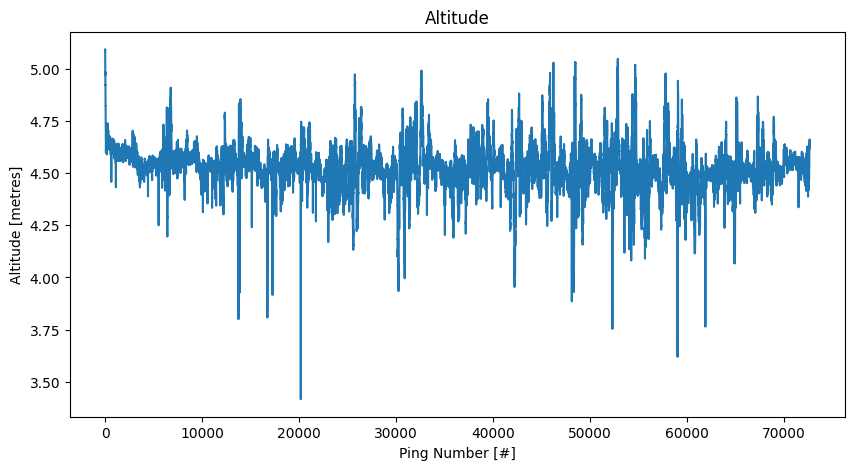

In [8]:
import matplotlib.pyplot as plt 

_, ax = plt.subplots(figsize=(10,5))

# Plot altitude
ax.plot(altitude)
ax.set_title("Altitude")
ax.set_xlabel("Ping Number [#]")
ax.set_ylabel("Altitude [metres]")

plt.show()

Plot orientation

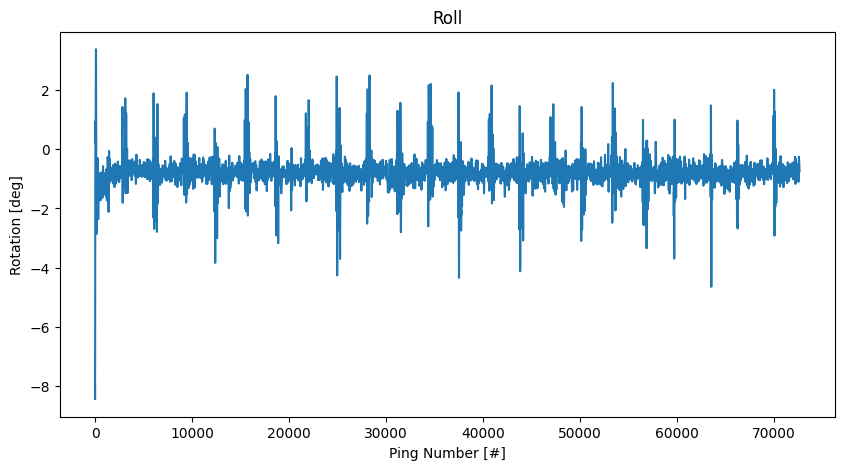

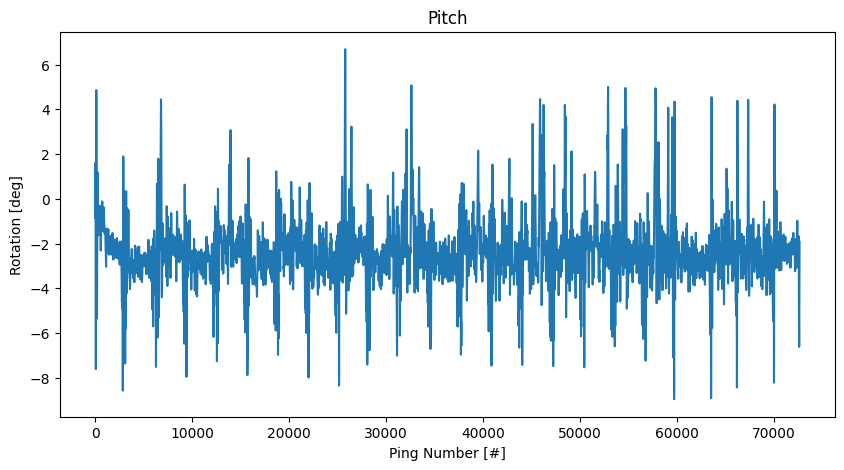

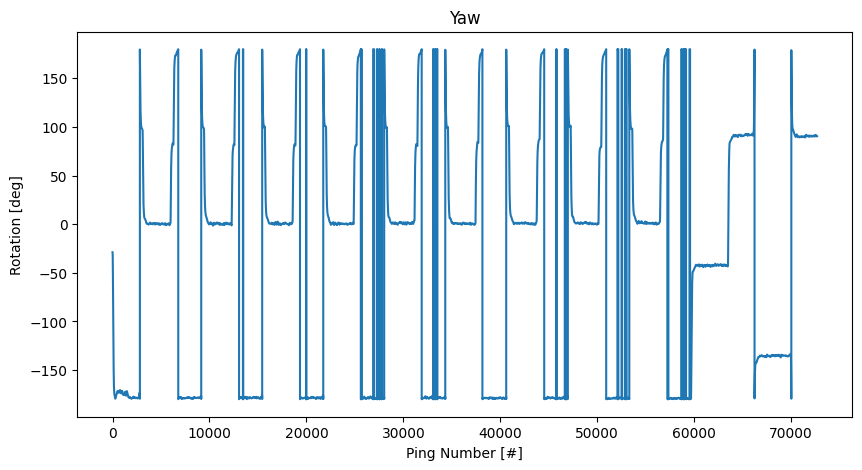

In [9]:
from math import pi 

# Plot orientations
_, ax = plt.subplots(figsize=(10,5))
ax.plot(roll*180/pi)
ax.set_title("Roll")
ax.set_xlabel("Ping Number [#]")
ax.set_ylabel("Rotation [deg]")

_, ax = plt.subplots(figsize=(10,5))
ax.plot(pitch*180/pi)
ax.set_title("Pitch")
ax.set_xlabel("Ping Number [#]")
ax.set_ylabel("Rotation [deg]")

_, ax = plt.subplots(figsize=(10,5))
ax.plot(yaw*180/pi)
ax.set_title("Yaw")
ax.set_xlabel("Ping Number [#]")
ax.set_ylabel("Rotation [deg]")

plt.show()

Plot the trajectory (X-Y)

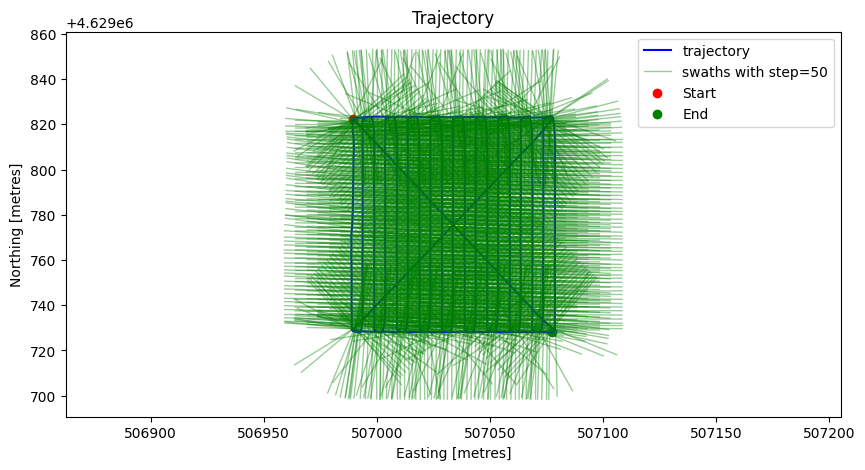

In [13]:

_, ax = plt.subplots(figsize=(10,5))

# Plot trajectory
ax.plot(trajectory[:,0], trajectory[:,1], color="blue", label="trajectory")

# Plot ping lines 
step = 50
for i in range(0, swaths.shape[0], step):
    start_point = swaths[i, 0, :]      
    end_point = swaths[i, -1, :]       
    
    x_vals = [start_point[0], end_point[0]]
    y_vals = [start_point[1], end_point[1]]
    
    if i == 0:
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1, label=f"swaths with step={step}")
    else:    
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1)

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.legend()

plt.show()

Show the waterfall image (both original and processed)

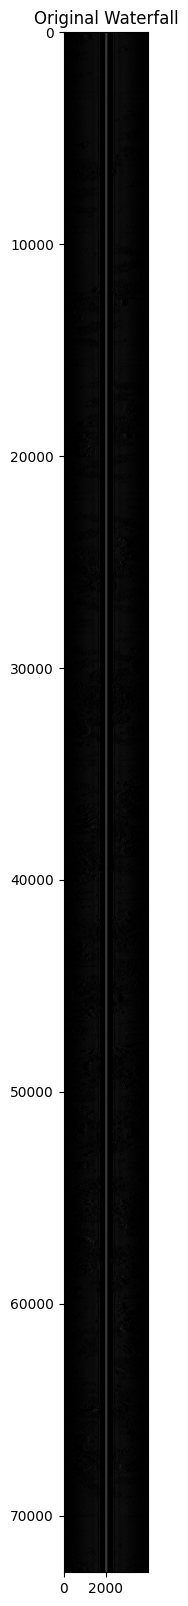

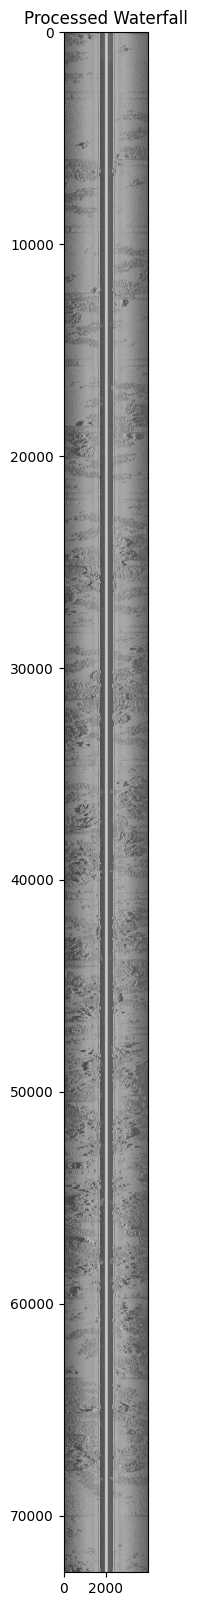

In [11]:
N = waterfall_img.shape[0]
ping_idx = slice(0, N)

# Plot original and processed images
_, ax1 = plt.subplots(figsize=(40,20))
ax1.imshow(sonar_img[ping_idx,:] , cmap="gray")
ax1.set_title("Original Waterfall")

_, ax2 = plt.subplots(figsize=(40,20))
ax2.imshow(waterfall_img[ping_idx,:] , cmap="gray")
ax2.set_title("Processed Waterfall")

plt.show()